In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

import spacy
from spacy import displacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import polyleven

# Working with text

## Live demos

In [5]:
with open('data/dracula.txt', 'r', encoding='utf-8') as f:
    dracula = f.read()

In [6]:
dracula

'The Project Gutenberg EBook of Dracula, by Bram Stoker\n\nCopyright laws are changing all over the world. Be sure to check the\ncopyright laws for your country before downloading or redistributing\nthis or any other Project Gutenberg eBook.\n\nThis header should be the first thing seen when viewing this Project\nGutenberg file.  Please do not remove it.  Do not change or edit the\nheader without written permission.\n\nPlease read the "legal small print," and other information about the\neBook and Project Gutenberg at the bottom of this file.  Included is\nimportant information about your specific rights and restrictions in\nhow the file may be used.  You can also find out about how to make a\ndonation to Project Gutenberg, and how to get involved.\n\n\n**Welcome To The World of Free Plain Vanilla Electronic Texts**\n\n**eBooks Readable By Both Humans and By Computers, Since 1971**\n\n*****These eBooks Were Prepared By Thousands of Volunteers!*****\n\n\nTitle: Dracula\n\nAuthor: Bram S

In [8]:
Counter(dracula)

Counter({' ': 156826,
         'e': 80047,
         't': 57083,
         'a': 51609,
         'o': 50787,
         'n': 43795,
         'h': 41852,
         's': 38951,
         'i': 37594,
         'r': 35112,
         'd': 28340,
         'l': 25724,
         'u': 18169,
         'w': 17058,
         'm': 16952,
         '\n': 16556,
         'f': 13939,
         'c': 13290,
         ',': 13034,
         'y': 12541,
         'g': 12394,
         '.': 9335,
         'p': 8914,
         'b': 8579,
         'k': 6212,
         'I': 5793,
         'v': 5566,
         '"': 2820,
         'T': 2112,
         'H': 1746,
         "'": 1673,
         'A': 1545,
         'W': 1171,
         'S': 1132,
         'M': 1074,
         '-': 842,
         'x': 813,
         'L': 790,
         '!': 740,
         'B': 658,
         'R': 630,
         'D': 608,
         'E': 606,
         'O': 595,
         'C': 581,
         'N': 547,
         'q': 544,
         'G': 501,
         '?': 499,
         'P

In [9]:
alice = ''
with open('data/alice.txt', 'r', encoding='utf-8') as f:
    alice = f.read()

In [10]:
Counter(alice)

Counter({' ': 29580,
         'e': 15243,
         't': 11754,
         'o': 9348,
         'a': 9172,
         'n': 7926,
         'i': 7881,
         'h': 7669,
         's': 7054,
         'r': 6481,
         'd': 5275,
         'l': 5111,
         'u': 3926,
         'c': 2843,
         'g': 2766,
         'w': 2725,
         ',': 2566,
         'y': 2489,
         'm': 2272,
         '\n': 2266,
         'f': 2259,
         'p': 1805,
         '’': 1768,
         'b': 1638,
         '.': 1217,
         'k': 1209,
         '‘': 1116,
         'v': 945,
         'I': 788,
         'A': 674,
         'T': 487,
         '!': 451,
         '—': 264,
         ':': 255,
         'H': 246,
         'W': 231,
         'S': 226,
         '-': 223,
         'j': 222,
         'D': 216,
         '?': 203,
         'E': 198,
         'M': 197,
         ';': 194,
         'C': 185,
         'P': 183,
         'G': 182,
         'x': 169,
         'R': 167,
         'O': 148,
         'N': 140,


In [13]:
dracula_words = dracula.split()

In [15]:
Counter(dracula_words)

Counter({'the': 7264,
         'and': 5599,
         'I': 4532,
         'to': 4403,
         'of': 3599,
         'a': 2878,
         'in': 2334,
         'that': 2302,
         'he': 1907,
         'was': 1793,
         'as': 1451,
         'is': 1427,
         'for': 1385,
         'it': 1371,
         'his': 1345,
         'not': 1292,
         'with': 1218,
         'we': 1194,
         'my': 1136,
         'have': 1039,
         'be': 1030,
         'you': 1023,
         'had': 1004,
         'at': 987,
         'all': 976,
         'on': 935,
         'so': 910,
         'me': 846,
         'her': 817,
         'but': 771,
         'which': 639,
         'He': 609,
         'The': 607,
         'from': 607,
         'she': 600,
         'him': 588,
         'are': 556,
         'were': 525,
         'when': 522,
         'if': 522,
         'or': 495,
         'there': 487,
         'by': 474,
         'could': 455,
         'this': 453,
         'must': 429,
         'would': 4

In [16]:
len(Counter(dracula_words))

17340

In [17]:
alice_words = alice.split()

In [18]:
len(Counter(alice_words))

5924

In [19]:
len(dracula), len(alice)

(852586, 164108)

In [20]:
[word for word in dracula_words]

['The',
 'Project',
 'Gutenberg',
 'EBook',
 'of',
 'Dracula,',
 'by',
 'Bram',
 'Stoker',
 'Copyright',
 'laws',
 'are',
 'changing',
 'all',
 'over',
 'the',
 'world.',
 'Be',
 'sure',
 'to',
 'check',
 'the',
 'copyright',
 'laws',
 'for',
 'your',
 'country',
 'before',
 'downloading',
 'or',
 'redistributing',
 'this',
 'or',
 'any',
 'other',
 'Project',
 'Gutenberg',
 'eBook.',
 'This',
 'header',
 'should',
 'be',
 'the',
 'first',
 'thing',
 'seen',
 'when',
 'viewing',
 'this',
 'Project',
 'Gutenberg',
 'file.',
 'Please',
 'do',
 'not',
 'remove',
 'it.',
 'Do',
 'not',
 'change',
 'or',
 'edit',
 'the',
 'header',
 'without',
 'written',
 'permission.',
 'Please',
 'read',
 'the',
 '"legal',
 'small',
 'print,"',
 'and',
 'other',
 'information',
 'about',
 'the',
 'eBook',
 'and',
 'Project',
 'Gutenberg',
 'at',
 'the',
 'bottom',
 'of',
 'this',
 'file.',
 'Included',
 'is',
 'important',
 'information',
 'about',
 'your',
 'specific',
 'rights',
 'and',
 'restrictions'

In [21]:
Counter(dracula_words)

Counter({'the': 7264,
         'and': 5599,
         'I': 4532,
         'to': 4403,
         'of': 3599,
         'a': 2878,
         'in': 2334,
         'that': 2302,
         'he': 1907,
         'was': 1793,
         'as': 1451,
         'is': 1427,
         'for': 1385,
         'it': 1371,
         'his': 1345,
         'not': 1292,
         'with': 1218,
         'we': 1194,
         'my': 1136,
         'have': 1039,
         'be': 1030,
         'you': 1023,
         'had': 1004,
         'at': 987,
         'all': 976,
         'on': 935,
         'so': 910,
         'me': 846,
         'her': 817,
         'but': 771,
         'which': 639,
         'He': 609,
         'The': 607,
         'from': 607,
         'she': 600,
         'him': 588,
         'are': 556,
         'were': 525,
         'when': 522,
         'if': 522,
         'or': 495,
         'there': 487,
         'by': 474,
         'could': 455,
         'this': 453,
         'must': 429,
         'would': 4

In [22]:
dracula_words = [word.lower() for word in dracula_words]

In [23]:
dracula_words = [word.strip('.,!?";()') for word in dracula_words]

In [24]:
Counter(dracula_words)

Counter({'the': 7929,
         'and': 5920,
         'i': 4739,
         'to': 4518,
         'of': 3662,
         'a': 2943,
         'he': 2555,
         'in': 2511,
         'that': 2453,
         'it': 2149,
         'was': 1877,
         'as': 1592,
         'we': 1543,
         'for': 1539,
         'is': 1511,
         'his': 1460,
         'me': 1446,
         'you': 1443,
         'not': 1413,
         'with': 1282,
         'my': 1252,
         'all': 1146,
         'be': 1129,
         'so': 1103,
         'at': 1082,
         'but': 1071,
         'on': 1070,
         'have': 1060,
         'her': 1056,
         'had': 1033,
         'him': 949,
         'she': 808,
         'when': 768,
         'there': 758,
         'if': 660,
         'which': 659,
         'this': 648,
         'from': 629,
         'are': 593,
         'said': 570,
         'were': 551,
         'then': 539,
         'by': 530,
         'or': 517,
         'could': 489,
         'one': 486,
         '

In [25]:
dracula_words = [word for word in dracula_words if word != '']

In [26]:
Counter(dracula_words)

Counter({'the': 7929,
         'and': 5920,
         'i': 4739,
         'to': 4518,
         'of': 3662,
         'a': 2943,
         'he': 2555,
         'in': 2511,
         'that': 2453,
         'it': 2149,
         'was': 1877,
         'as': 1592,
         'we': 1543,
         'for': 1539,
         'is': 1511,
         'his': 1460,
         'me': 1446,
         'you': 1443,
         'not': 1413,
         'with': 1282,
         'my': 1252,
         'all': 1146,
         'be': 1129,
         'so': 1103,
         'at': 1082,
         'but': 1071,
         'on': 1070,
         'have': 1060,
         'her': 1056,
         'had': 1033,
         'him': 949,
         'she': 808,
         'when': 768,
         'there': 758,
         'if': 660,
         'which': 659,
         'this': 648,
         'from': 629,
         'are': 593,
         'said': 570,
         'were': 551,
         'then': 539,
         'by': 530,
         'or': 517,
         'could': 489,
         'one': 486,
         '

In [27]:
dracula_counter = Counter(dracula_words)    

In [28]:
dracula_counter.keys()

dict_keys(['the', 'project', 'gutenberg', 'ebook', 'of', 'dracula', 'by', 'bram', 'stoker', 'copyright', 'laws', 'are', 'changing', 'all', 'over', 'world', 'be', 'sure', 'to', 'check', 'for', 'your', 'country', 'before', 'downloading', 'or', 'redistributing', 'this', 'any', 'other', 'header', 'should', 'first', 'thing', 'seen', 'when', 'viewing', 'file', 'please', 'do', 'not', 'remove', 'it', 'change', 'edit', 'without', 'written', 'permission', 'read', 'legal', 'small', 'print', 'and', 'information', 'about', 'at', 'bottom', 'included', 'is', 'important', 'specific', 'rights', 'restrictions', 'in', 'how', 'may', 'used', 'you', 'can', 'also', 'find', 'out', 'make', 'a', 'donation', 'get', 'involved', '**welcome', 'free', 'plain', 'vanilla', 'electronic', 'texts**', '**ebooks', 'readable', 'both', 'humans', 'computers', 'since', '1971**', '*****these', 'ebooks', 'were', 'prepared', 'thousands', 'volunteers!*****', 'title:', 'author:', 'release', 'date:', 'october', '1995', '[ebook', '#3

In [30]:
len(list(dracula_counter.keys()))

10364

In [31]:
dracula_counter.most_common(10)

[('the', 7929),
 ('and', 5920),
 ('i', 4739),
 ('to', 4518),
 ('of', 3662),
 ('a', 2943),
 ('he', 2555),
 ('in', 2511),
 ('that', 2453),
 ('it', 2149)]

In [37]:
vocabulary = list(dracula_counter.keys())

In [39]:
nltk.download('stopwords')
sw = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [41]:
cleaned_vocabulary = [word for word in vocabulary if word not in sw]

In [42]:
cleaned_vocabulary

['project',
 'gutenberg',
 'ebook',
 'dracula',
 'bram',
 'stoker',
 'copyright',
 'laws',
 'changing',
 'world',
 'sure',
 'check',
 'country',
 'downloading',
 'redistributing',
 'header',
 'first',
 'thing',
 'seen',
 'viewing',
 'file',
 'please',
 'remove',
 'change',
 'edit',
 'without',
 'written',
 'permission',
 'read',
 'legal',
 'small',
 'print',
 'information',
 'bottom',
 'included',
 'important',
 'specific',
 'rights',
 'restrictions',
 'may',
 'used',
 'also',
 'find',
 'make',
 'donation',
 'get',
 'involved',
 '**welcome',
 'free',
 'plain',
 'vanilla',
 'electronic',
 'texts**',
 '**ebooks',
 'readable',
 'humans',
 'computers',
 'since',
 '1971**',
 '*****these',
 'ebooks',
 'prepared',
 'thousands',
 'volunteers!*****',
 'title:',
 'author:',
 'release',
 'date:',
 'october',
 '1995',
 '[ebook',
 '#345]',
 '[most',
 'recently',
 'updated:',
 'november',
 '28',
 '2003]',
 'edition:',
 '13',
 'language:',
 'english',
 'character',
 'set',
 'encoding:',
 'us-ascii',


In [43]:
dracula_counter['cost']

2

In [44]:
[dracula_counter[word] for word in cleaned_vocabulary]

[39,
 27,
 31,
 35,
 3,
 3,
 10,
 3,
 3,
 62,
 47,
 7,
 24,
 1,
 1,
 3,
 136,
 97,
 93,
 1,
 5,
 29,
 6,
 45,
 1,
 140,
 31,
 6,
 84,
 9,
 50,
 9,
 16,
 4,
 4,
 13,
 2,
 4,
 1,
 421,
 48,
 46,
 115,
 165,
 2,
 178,
 2,
 1,
 42,
 7,
 1,
 1,
 1,
 1,
 4,
 2,
 1,
 88,
 1,
 1,
 17,
 25,
 9,
 1,
 1,
 1,
 7,
 1,
 22,
 1,
 1,
 1,
 1,
 3,
 1,
 9,
 7,
 1,
 1,
 5,
 1,
 18,
 2,
 66,
 1,
 1,
 5,
 28,
 1,
 1,
 1,
 1,
 1,
 2,
 27,
 19,
 180,
 53,
 50,
 10,
 1,
 1,
 1,
 3,
 1,
 2,
 1,
 35,
 40,
 96,
 21,
 1,
 36,
 56,
 59,
 5,
 72,
 27,
 135,
 7,
 158,
 166,
 489,
 18,
 4,
 29,
 280,
 92,
 23,
 433,
 51,
 7,
 389,
 32,
 3,
 23,
 13,
 11,
 30,
 3,
 3,
 1,
 10,
 21,
 1,
 4,
 222,
 473,
 12,
 3,
 3,
 3,
 97,
 27,
 222,
 305,
 1,
 1,
 42,
 211,
 12,
 1,
 32,
 26,
 17,
 3,
 127,
 225,
 72,
 2,
 3,
 6,
 2,
 213,
 141,
 1,
 570,
 44,
 3,
 1,
 1,
 3,
 47,
 15,
 56,
 9,
 153,
 1,
 4,
 11,
 52,
 399,
 5,
 66,
 5,
 4,
 2,
 196,
 28,
 18,
 6,
 8,
 15,
 15,
 33,
 1,
 26,
 18,
 6,
 3,
 2,
 2,
 4,
 2,
 1,
 61,
 12,


In [45]:
{word: dracula_counter[word] for word in cleaned_vocabulary}

{'project': 39,
 'gutenberg': 27,
 'ebook': 31,
 'dracula': 35,
 'bram': 3,
 'stoker': 3,
 'copyright': 10,
 'laws': 3,
 'changing': 3,
 'world': 62,
 'sure': 47,
 'check': 7,
 'country': 24,
 'downloading': 1,
 'redistributing': 1,
 'header': 3,
 'first': 136,
 'thing': 97,
 'seen': 93,
 'viewing': 1,
 'file': 5,
 'please': 29,
 'remove': 6,
 'change': 45,
 'edit': 1,
 'without': 140,
 'written': 31,
 'permission': 6,
 'read': 84,
 'legal': 9,
 'small': 50,
 'print': 9,
 'information': 16,
 'bottom': 4,
 'included': 4,
 'important': 13,
 'specific': 2,
 'rights': 4,
 'restrictions': 1,
 'may': 421,
 'used': 48,
 'also': 46,
 'find': 115,
 'make': 165,
 'donation': 2,
 'get': 178,
 'involved': 2,
 '**welcome': 1,
 'free': 42,
 'plain': 7,
 'vanilla': 1,
 'electronic': 1,
 'texts**': 1,
 '**ebooks': 1,
 'readable': 4,
 'humans': 2,
 'computers': 1,
 'since': 88,
 '1971**': 1,
 '*****these': 1,
 'ebooks': 17,
 'prepared': 25,
 'thousands': 9,
 'volunteers!*****': 1,
 'title:': 1,
 'autho

In [49]:
porter = PorterStemmer()
snowball = SnowballStemmer('english')
wordnet = WordNetLemmatizer()

In [50]:
porter.stem('care')

'care'

In [51]:
porter.stem('careless')

'careless'

In [52]:
porter.stem('carelessness')

'careless'

In [56]:
porter.stem('don\'t')

"don't"

In [57]:
porter.stem('am')

'am'

In [58]:
porter.stem('slyly')

'slyli'

In [59]:
porter.stem('spy')

'spi'

In [60]:
porter.stem('spies')

'spi'

In [61]:
porter.stem('spice')

'spice'

In [62]:
snowball.stem('care')

'care'

In [63]:
snowball.stem('careful')

'care'

In [64]:
snowball.stem('careless')

'careless'

In [65]:
snowball.stem('carelessness')

'careless'

In [66]:
[porter.stem(word) for word in cleaned_vocabulary]

['project',
 'gutenberg',
 'ebook',
 'dracula',
 'bram',
 'stoker',
 'copyright',
 'law',
 'chang',
 'world',
 'sure',
 'check',
 'countri',
 'download',
 'redistribut',
 'header',
 'first',
 'thing',
 'seen',
 'view',
 'file',
 'pleas',
 'remov',
 'chang',
 'edit',
 'without',
 'written',
 'permiss',
 'read',
 'legal',
 'small',
 'print',
 'inform',
 'bottom',
 'includ',
 'import',
 'specif',
 'right',
 'restrict',
 'may',
 'use',
 'also',
 'find',
 'make',
 'donat',
 'get',
 'involv',
 '**welcom',
 'free',
 'plain',
 'vanilla',
 'electron',
 'texts**',
 '**ebook',
 'readabl',
 'human',
 'comput',
 'sinc',
 '1971**',
 '*****these',
 'ebook',
 'prepar',
 'thousand',
 'volunteers!*****',
 'title:',
 'author:',
 'releas',
 'date:',
 'octob',
 '1995',
 '[ebook',
 '#345]',
 '[most',
 'recent',
 'updated:',
 'novemb',
 '28',
 '2003]',
 'edition:',
 '13',
 'language:',
 'english',
 'charact',
 'set',
 'encoding:',
 'us-ascii',
 '***',
 'start',
 'e-test',
 'revis',
 'voltag',
 'spike',
 '189

In [68]:
dracula_words_stems = [porter.stem(word) for word in dracula_words]

In [69]:
dracula_words_stems

['the',
 'project',
 'gutenberg',
 'ebook',
 'of',
 'dracula',
 'by',
 'bram',
 'stoker',
 'copyright',
 'law',
 'are',
 'chang',
 'all',
 'over',
 'the',
 'world',
 'be',
 'sure',
 'to',
 'check',
 'the',
 'copyright',
 'law',
 'for',
 'your',
 'countri',
 'befor',
 'download',
 'or',
 'redistribut',
 'thi',
 'or',
 'ani',
 'other',
 'project',
 'gutenberg',
 'ebook',
 'thi',
 'header',
 'should',
 'be',
 'the',
 'first',
 'thing',
 'seen',
 'when',
 'view',
 'thi',
 'project',
 'gutenberg',
 'file',
 'pleas',
 'do',
 'not',
 'remov',
 'it',
 'do',
 'not',
 'chang',
 'or',
 'edit',
 'the',
 'header',
 'without',
 'written',
 'permiss',
 'pleas',
 'read',
 'the',
 'legal',
 'small',
 'print',
 'and',
 'other',
 'inform',
 'about',
 'the',
 'ebook',
 'and',
 'project',
 'gutenberg',
 'at',
 'the',
 'bottom',
 'of',
 'thi',
 'file',
 'includ',
 'is',
 'import',
 'inform',
 'about',
 'your',
 'specif',
 'right',
 'and',
 'restrict',
 'in',
 'how',
 'the',
 'file',
 'may',
 'be',
 'use',
 

In [70]:
dracula_words_stems = [word for word in dracula_words_stems if word not in sw]

In [71]:
Counter(dracula_words_stems)

Counter({'wa': 1877,
         'hi': 1460,
         'thi': 648,
         'said': 570,
         'one': 497,
         'could': 489,
         'come': 483,
         'us': 473,
         'look': 452,
         'time': 445,
         'know': 445,
         'must': 441,
         'would': 433,
         'see': 432,
         'shall': 422,
         'may': 421,
         'seem': 387,
         'go': 349,
         'ha': 346,
         'hand': 336,
         'van': 321,
         'came': 305,
         'hels': 299,
         'went': 298,
         'ani': 297,
         'like': 296,
         'onli': 287,
         'befor': 276,
         'even': 276,
         'thing': 275,
         'veri': 273,
         'back': 266,
         'room': 252,
         'think': 252,
         'way': 247,
         'say': 240,
         'well': 239,
         'tell': 238,
         'good': 237,
         'ask': 231,
         'sleep': 225,
         'get': 224,
         'night': 224,
         'took': 223,
         'day': 223,
         'man': 223,


In [77]:
nlp = spacy.load('en_core_web_sm')

In [93]:
document = nlp("The black cat sat on the mat in Bulgaria.")

In [83]:
for token in document:
    print(token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
          token.shape_, token.is_alpha, token.is_stop, token.orth_)

The the DET DT det Xxx True True The
black black ADJ JJ amod xxxx True False black
cat cat NOUN NN nsubj xxx True False cat
sat sit VERB VBD ROOT xxx True False sat
on on ADP IN prep xx True True on
the the DET DT det xxx True True the
mat mat NOUN NN pobj xxx True False mat
. . PUNCT . punct . False False .


In [91]:
displacy.render(document, style='dep', jupyter=True)

In [94]:
displacy.render(document, style='ent')

In [97]:
imdb = pd.read_csv('data/IMDB Dataset.csv')

In [98]:
imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [99]:
imdb.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

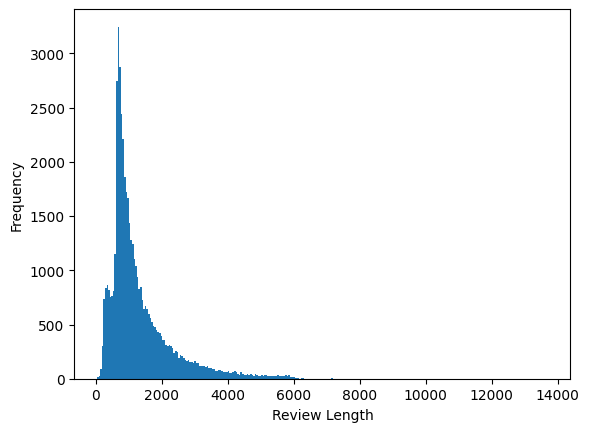

In [102]:
plt.hist(imdb.review.str.len(), bins='fd')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

In [113]:
count_vectorizer = CountVectorizer(stop_words='english',min_df=3, max_df=0.5)

In [116]:
count_vectorizer.fit(imdb.review)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [117]:
count_vectorizer.vocabulary_

{'reviewers': 35490,
 'mentioned': 26944,
 'watching': 46139,
 'just': 23127,
 'oz': 30437,
 'episode': 14340,
 'll': 25024,
 'hooked': 20280,
 'right': 35686,
 'exactly': 14726,
 'happened': 19158,
 'thing': 42541,
 'struck': 40788,
 'brutality': 5827,
 'unflinching': 44497,
 'scenes': 36957,
 'violence': 45625,
 'set': 37686,
 'word': 46950,
 'trust': 43759,
 'faint': 15238,
 'hearted': 19497,
 'timid': 42803,
 'pulls': 33433,
 'punches': 33462,
 'regards': 34669,
 'drugs': 13022,
 'sex': 37737,
 'hardcore': 19193,
 'classic': 7881,
 'use': 45037,
 'called': 6332,
 'nickname': 28972,
 'given': 17804,
 'oswald': 30094,
 'maximum': 26523,
 'security': 37382,
 'state': 40255,
 'focuses': 16367,
 'mainly': 25799,
 'emerald': 13881,
 'city': 7805,
 'experimental': 14951,
 'section': 37372,
 'prison': 32922,
 'cells': 7007,
 'glass': 17847,
 'fronts': 16948,
 'face': 15175,
 'privacy': 32930,
 'high': 19862,
 'agenda': 1220,
 'em': 13817,
 'home': 20179,
 'aryans': 2633,
 'muslims': 28348,

In [120]:
len(count_vectorizer.vocabulary_)

47621

In [107]:
count_vectorizer.transform(imdb.review[:10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1038 stored elements and shape (10, 101895)>

In [108]:
count_vectorizer.transform(imdb.review[:10]).toarray().shape

(10, 101895)

In [119]:
count_vectorizer.transform(imdb.review[:10]).toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(10, 47621))

In [118]:
count_vectorizer.get_feature_names_out()

array(['00', '000', '001', ..., 'émigrés', 'était', 'über'],
      shape=(47621,), dtype=object)

In [121]:
dracula[250000:]

'no matter on what ground he comes, we must accept his\nwishes.  He is a seemingly arbitrary man, this is because he knows\nwhat he is talking about better than any one else.  He is a\nphilosopher and a metaphysician, and one of the most advanced\nscientists of his day, and he has, I believe, an absolutely open\nmind.  This, with an iron nerve, a temper of the ice-brook, and\nindomitable resolution, self-command, and toleration exalted from\nvirtues to blessings, and the kindliest and truest heart that beats,\nthese form his equipment for the noble work that he is doing for\nmankind, work both in theory and practice, for his views are as wide\nas his all-embracing sympathy.  I tell you these facts that you may\nknow why I have such confidence in him.  I have asked him to come at\nonce.  I shall see Miss Westenra tomorrow again.  She is to meet me\nat the Stores, so that I may not alarm her mother by too early a\nrepetition of my call.\n\n"Yours always."\n\nJohn Seward\n\n\n\n\nLETTER, 

In [122]:
count_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 4))

In [123]:
count_vectorizer.fit(imdb.review[:10])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [124]:
len(count_vectorizer.vocabulary_)

2746

In [126]:
count_vectorizer.vocabulary_

{'reviewers': 1960,
 'mentioned': 1468,
 'watching': 2584,
 'just': 1199,
 'oz': 1646,
 'episode': 728,
 'll': 1344,
 'hooked': 1090,
 'right': 1968,
 'exactly': 735,
 'happened': 1033,
 'br': 215,
 'thing': 2354,
 'struck': 2242,
 'brutality': 322,
 'unflinching': 2492,
 'scenes': 2031,
 'violence': 2529,
 'set': 2106,
 'word': 2670,
 'trust': 2462,
 'faint': 778,
 'hearted': 1061,
 'timid': 2420,
 'pulls': 1869,
 'punches': 1873,
 'regards': 1925,
 'drugs': 681,
 'sex': 2114,
 'hardcore': 1049,
 'classic': 417,
 'use': 2496,
 'called': 330,
 'nickname': 1582,
 'given': 922,
 'oswald': 1638,
 'maximum': 1452,
 'security': 2071,
 'state': 2222,
 'penitentary': 1706,
 'focuses': 864,
 'mainly': 1396,
 'emerald': 699,
 'city': 403,
 'experimental': 754,
 'section': 2067,
 'prison': 1837,
 'cells': 361,
 'glass': 934,
 'fronts': 891,
 'face': 770,
 'inwards': 1163,
 'privacy': 1847,
 'high': 1076,
 'agenda': 58,
 'em': 695,
 'home': 1083,
 'aryans': 107,
 'muslims': 1552,
 'gangstas': 911

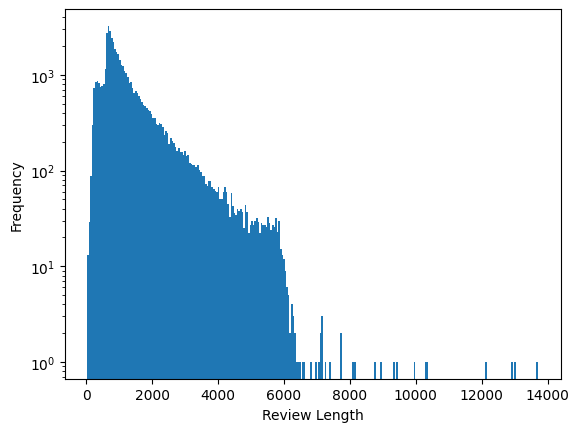

In [127]:
plt.hist(imdb.review.str.len(), bins='fd')
plt.semilogy()
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

In [132]:
tfidf_vectorizer = TfidfVectorizer(min_df=3, max_df=9)

In [133]:
tfidf_vectorizer.fit(imdb.review[:10])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [130]:
len(count_vectorizer.vocabulary_)

2746

In [134]:
len(tfidf_vectorizer.vocabulary_)

77

In [135]:
tfidf_vectorizer.transform(imdb.review[:10]).toarray().shape

(10, 77)

In [136]:
tfidf_vectorizer.transform(imdb.review[:10]).toarray()

array([[0.04565192, 0.04565192, 0.05083413, 0.18679498, 0.06825441,
        0.18260769, 0.07495001, 0.20476323, 0.08254086, 0.        ,
        0.05717664, 0.        , 0.05717664, 0.        , 0.11435328,
        0.18737503, 0.05717664, 0.05717664, 0.        , 0.05083413,
        0.04565192, 0.        , 0.04127043, 0.10238162, 0.28019246,
        0.20476323, 0.11435328, 0.10166826, 0.        , 0.        ,
        0.05717664, 0.22870657, 0.10166826, 0.        , 0.        ,
        0.        , 0.05717664, 0.05717664, 0.12381129, 0.21792747,
        0.        , 0.11242502, 0.03747501, 0.        , 0.11242502,
        0.04565192, 0.11435328, 0.        , 0.15250239, 0.        ,
        0.        , 0.16508172, 0.49811994, 0.05717664, 0.        ,
        0.        , 0.04565192, 0.05717664, 0.09339749, 0.        ,
        0.18679498, 0.        , 0.        , 0.        , 0.15250239,
        0.10166826, 0.        , 0.        , 0.05083413, 0.10166826,
        0.        , 0.11435328, 0.05083413, 0.18

In [137]:
tfidf_vectorizer.transform(imdb.review[:10]).toarray()[0]

array([0.04565192, 0.04565192, 0.05083413, 0.18679498, 0.06825441,
       0.18260769, 0.07495001, 0.20476323, 0.08254086, 0.        ,
       0.05717664, 0.        , 0.05717664, 0.        , 0.11435328,
       0.18737503, 0.05717664, 0.05717664, 0.        , 0.05083413,
       0.04565192, 0.        , 0.04127043, 0.10238162, 0.28019246,
       0.20476323, 0.11435328, 0.10166826, 0.        , 0.        ,
       0.05717664, 0.22870657, 0.10166826, 0.        , 0.        ,
       0.        , 0.05717664, 0.05717664, 0.12381129, 0.21792747,
       0.        , 0.11242502, 0.03747501, 0.        , 0.11242502,
       0.04565192, 0.11435328, 0.        , 0.15250239, 0.        ,
       0.        , 0.16508172, 0.49811994, 0.05717664, 0.        ,
       0.        , 0.04565192, 0.05717664, 0.09339749, 0.        ,
       0.18679498, 0.        , 0.        , 0.        , 0.15250239,
       0.10166826, 0.        , 0.        , 0.05083413, 0.10166826,
       0.        , 0.11435328, 0.05083413, 0.18737503, 0.     

In [143]:
tfidf_vectorizer.transform([imdb.review[0]]).toarray()[0].ravel()

array([0.04565192, 0.04565192, 0.05083413, 0.18679498, 0.06825441,
       0.18260769, 0.07495001, 0.20476323, 0.08254086, 0.        ,
       0.05717664, 0.        , 0.05717664, 0.        , 0.11435328,
       0.18737503, 0.05717664, 0.05717664, 0.        , 0.05083413,
       0.04565192, 0.        , 0.04127043, 0.10238162, 0.28019246,
       0.20476323, 0.11435328, 0.10166826, 0.        , 0.        ,
       0.05717664, 0.22870657, 0.10166826, 0.        , 0.        ,
       0.        , 0.05717664, 0.05717664, 0.12381129, 0.21792747,
       0.        , 0.11242502, 0.03747501, 0.        , 0.11242502,
       0.04565192, 0.11435328, 0.        , 0.15250239, 0.        ,
       0.        , 0.16508172, 0.49811994, 0.05717664, 0.        ,
       0.        , 0.04565192, 0.05717664, 0.09339749, 0.        ,
       0.18679498, 0.        , 0.        , 0.        , 0.15250239,
       0.10166826, 0.        , 0.        , 0.05083413, 0.10166826,
       0.        , 0.11435328, 0.05083413, 0.18737503, 0.     

In [145]:
features = list(zip(tfidf_vectorizer.vocabulary_, tfidf_vectorizer.transform(imdb.review[:1]).toarray()[0]))

In [150]:
pd.DataFrame(features, columns=["token", "tfidf"]).sort_values("tfidf", ascending=False)[:20]

,token,tfidf
52,time,0.498120
24,which,0.280192
31,to,0.228707
39,many,0.217927
7,you,0.204763
25,in,0.204763
15,with,0.187375
73,them,0.187375
60,then,0.186795
3,has,0.186795


In [147]:
features

[('one', np.float64(0.04565192352256632)),
 ('of', np.float64(0.04565192352256632)),
 ('the', np.float64(0.05083413149574688)),
 ('has', np.float64(0.18679497630559974)),
 ('that', np.float64(0.0682544111689432)),
 ('watching', np.float64(0.18260769409026528)),
 ('just', np.float64(0.07495001203169491)),
 ('you', np.float64(0.20476323350682957)),
 ('be', np.float64(0.08254085822341248)),
 ('they', np.float64(0.0)),
 ('are', np.float64(0.05717664146066105)),
 ('as', np.float64(0.0)),
 ('this', np.float64(0.05717664146066105)),
 ('is', np.float64(0.0)),
 ('what', np.float64(0.1143532829213221)),
 ('with', np.float64(0.18737503007923725)),
 ('me', np.float64(0.05717664146066105)),
 ('br', np.float64(0.05717664146066105)),
 ('first', np.float64(0.0)),
 ('thing', np.float64(0.05083413149574688)),
 ('about', np.float64(0.04565192352256632)),
 ('was', np.float64(0.0)),
 ('its', np.float64(0.04127042911170624)),
 ('and', np.float64(0.10238161675341478)),
 ('which', np.float64(0.280192464458399

In [158]:
polyleven.levenshtein('kitten', 'sitting')

3

In [159]:
polyleven.levenshtein('a', 'b')

1

In [160]:
nlp("The black cat sat on the mat in Bulgaria.")

The black cat sat on the mat in Bulgaria.

In [162]:
displacy.render(nlp("The black cat sat on the mat in Bulgaria."))

In [163]:
displacy.render(nlp("Time flies like an arrow. Fruit flies like a banana."))

In [164]:
displacy.render(nlp("Buffalo buffalo Buffalo buffalo."))